## Projeto Final (RideSmart) — EasyPath

### Modelagem e Análise de Rotas Urbanas com Grafos

A ideia é simular um problema inspirado em aplicativos de mobilidade urbana:

> Dado um ponto de origem `A`, um destino `B` e uma distância máxima que o usuário aceita caminhar, escolher o melhor ponto de embarque `P`.

#### Grupo
-  Felipe Gabriel Bezerra Da Silva
- José Felix Rodrigues Anselmo
- Laíze Suélia da Silva Oliveira
- Lucas Henrique Alvez De Queiroz


## 1. Instalação e Importações

In [1]:
!pip install osmnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.2 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import heapq
import math
import random
import time
from collections import defaultdict

print("=" * 50)
print(" ==== Bibliotecas Importadas com Sucesso! ==== ")
print("=" * 50)


 ==== Bibliotecas Importadas com Sucesso! ==== 


## 2. Modelagem do Grafo Urbano

### Como o problema é modelado como grafo?

- **Nós**: interseções e cruzamentos de ruas de Natal/RN
- **Arestas**: segmentos de via, com peso `length` (distância em metros)
  e `travel_time` (tempo em segundos, calculado com velocidade da via)
- **Pesos de custo**:
  - `length` → menor distância
  - `travel_time` → menor tempo sem trânsito
  - `traffic_time` → menor tempo com trânsito sintético


In [3]:
ox.settings.use_cache = True

# Baixar grafo de direção (carro) de Natal
place = "Natal, Rio Grande do Norte, Brazil"
G = ox.graph_from_place(place, network_type='drive')

# Adicionar velocidades e tempos de percurso
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

print("=" * 50)
print(" ==== Grafo carregado com sucesso! ==== ")
print("=" * 50)
print(f"\nNós: {G.number_of_nodes()} | Arestas: {G.number_of_edges()}")


 ==== Grafo carregado com sucesso! ==== 

Nós: 18581 | Arestas: 48193


## 3. Pontos de Embarque de Carro (Táxi / Ride-sharing)


In [4]:
# ============================================================
#    Obter POIs(Pontos de interesse) ou (pontos de embarque de carro)
#    Prioridade: táxi → estacionamento → amostra do grafo
# ============================================================

pickup_points = []

# Pontos de táxi
for tag in [{"amenity": "taxi"}, {"amenity": "parking"}, {"amenity": "car_rental"}]:
    if len(pickup_points) >= 30:
        break
    try:
        pois = ox.features.features_from_place(place, tags=tag)
        for idx, row in pois.iterrows():
            #Buscar os pontos de interesse
            geom = row.geometry if row.geometry.geom_type == "Point" else row.geometry.centroid
            pickup_points.append((geom.y, geom.x))
        print(f"{tag}: {len(pois)} POIs(Pontos de Interesse) encontrados")
    except Exception as e:
        print(f"{tag}: Não foram encontrados pontos de interesse({e})")

#Coletar mais amostra dos nós do grafo de direção se necessario
if len(pickup_points) < 10:
    print("Amostrando nós do grafo de direção como pontos de embarque.")
    random.seed(42)
    sample_nodes = random.sample(list(G.nodes), 200)
    pickup_points = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in sample_nodes]

print(f"\nTotal de pontos de embarque coletados: {len(pickup_points)}")

# Mapear cada ponto ao nó mais próximo do grafo de direção
lats = [p[0] for p in pickup_points]
lons = [p[1] for p in pickup_points]

pickup_nodes = list(set(ox.distance.nearest_nodes(G, X=lons, Y=lats)))
print(f"Nós únicos de embarque: {len(pickup_nodes)}")


{'amenity': 'taxi'}: 19 POIs(Pontos de Interesse) encontrados
{'amenity': 'parking'}: 672 POIs(Pontos de Interesse) encontrados

Total de pontos de embarque coletados: 691
Nós únicos de embarque: 570


## 4. Trânsito Sintético

O modelo combina **6 componentes** para gerar um congestionamento
espacialmente realista e academicamente justificável:

| Componente | Referência |
|---|---|
| Capacidade por classe de via (`highway`) | HCM 6th Ed. (TRB, 2016) |
| Fator temporal por período do dia | DNIT — Manual de Estudos de Tráfego (2006) |
| Centralidade de intermediação das arestas (k-sampling) | Brandes (2001), J. Math. Sociology |
| Hotspots com decaimento gaussiano espacial | Sheffi (1985), Urban Transportation Networks |
| Fluxo OD sintético (equilíbrio de Wardrop) | Wardrop (1952), Proc. ICE |
| Função BPR: `t = t₀·(1 + α·(v/c)^β)` | Bureau of Public Roads (1964) |

A função final é:
```
traffic_time = BPR(travel_time, fluxo_efetivo, capacidade)
fluxo_efetivo = capacidade·0.4·tf · (1 + 2·bet) · (1 + 2·hs) + od_contrib
```
onde `tf` = fator temporal, `bet` = centralidade, `hs` = fator de hotspot.



In [5]:
random.seed(42)
np.random.seed(42)

# =====================================================
# CLASSIFICAÇÃO DAS VIAS
# Identifica BRs pelo atributo 'ref' do OSM. Em Natal: BR-101 (norte-sul), BR-226 (oeste),
# BR-406 (zona norte / Extremoz).
# =====================================================

REFS_BR = {"BR-101", "BR-226", "BR-406", "BR 101", "BR 226", "BR 406", "101",    "226",    "406"}

def identificar_tipo_via(G):
    """
    Classifica cada aresta em uma das cinco categorias,
    priorizando o atributo 'ref' para detectar BRs federais.
    """
    for u, v, k, data in G.edges(keys=True, data=True):
        hw   = data.get("highway", "residential")
        ref  = str(data.get("ref",  "")).upper()
        nome = str(data.get("name", "")).upper()

        if isinstance(hw, list):
            hw = hw[0]
        hw = str(hw).strip()

        # Verifica se é rodovia federal (BR)
        eh_br = any(r in ref or r in nome for r in REFS_BR)

        if eh_br or hw in ("motorway", "motorway_link"):
            data["categoria_via"] = "br_federal"
        elif hw in ("trunk", "trunk_link"):
            data["categoria_via"] = "arterial_principal"
        elif hw in ("primary", "primary_link"):
            data["categoria_via"] = "arterial"
        elif hw in ("secondary", "secondary_link",
                    "tertiary",  "tertiary_link"):
            data["categoria_via"] = "coletora"
        else:
            data["categoria_via"] = "local"


# =====================================================
# CAPACIDADE DAS VIAS (HCM 6th Ed.)
# =====================================================
ROAD_CAPACITY = {
    "motorway":       4000, "motorway_link":  1800,
    "trunk":          3000, "trunk_link":     1200,
    "primary":        2500, "primary_link":   1000,
    "secondary":      1800, "secondary_link":  700,
    "tertiary":       1200, "tertiary_link":   500,
    "residential":     600,
    "living_street":   200,
    "service":         300,
    "unclassified":    500,
}

_CAP_DEFAULT = 600

def assign_road_capacity(G):
    """Atribui capacidade sintética (veíc./hora) a cada aresta."""
    for u, v, k, data in G.edges(keys=True, data=True):
        hw = data.get("highway", "residential")
        if isinstance(hw, list):
            hw = hw[0]
        data["road_capacity"] = ROAD_CAPACITY.get(str(hw).strip(), _CAP_DEFAULT)


# =====================================================
# FATOR TEMPORAL
# Ref: DNIT — Manual de Estudos de Tráfego (2006)
# Usado para tornar o trafico sintetico mais perto do Real
# =====================================================

TIME_FACTORS = {
    "madrugada":  0.15,
    "manha":      0.55,
    "pico_manha": 1.00,
    "meio_dia":   0.70,
    "tarde":      0.65,
    "pico_tarde": 0.95,
    "noite":      0.38,
}

def get_time_factor(period):
    return TIME_FACTORS.get(period, 1.0)


# =====================================================
# CENTRALIDADE (k-amostragem)
# Ref: Brandes (2001)
# mede a centralidade de intermediação, calculando a frequência
# com que um nó atua como ponte no caminho mais curto em uma rede.
# =====================================================

def compute_edge_betweenness(G, k=300):
    """Centralidade de intermediação com amostragem k-nós."""

    print(f"  Centralidade (k={k} amostras — aprox.)...")
    bc = nx.edge_betweenness_centrality(G, k=k, weight="travel_time", seed=42, normalized=True)

    v_max = max(bc.values()) if bc else 1.0
    v_max = v_max if v_max > 0 else 1.0

    for u, v, k_e, data in G.edges(keys=True, data=True):
        data["betweenness"] = bc.get((u, v), 0.0) / v_max


# =====================================================
# HOTSPOTS (pontos fixos em Natal + gaussiano)
#
# MELHORIA: hotspots deixam de ser aleatórios e passam a
# ser ancorados nos corredores congestionados reais:
#   - BR-101 Norte (acesso Zona Norte / Igapó)
#   - BR-101 / Av. Hermes da Fonseca (entrada sul da cidade)
#   - BR-101 / Av. Salgado Filho (cruzamento central)
#   - BR-101 Sul / Via Costeira
#   - BR-226 / Av. Bernardo Vieira (acesso oeste)
#   - BR-406 / Extremoz (Zona Norte)
#
# Cada centro tem uma intensidade própria (peso ≥ 1).
# sigma = 0.012° ≈ 1,3 km cobre o corredor típico de uma BR.
# =====================================================

# Localizando as vias
HOTSPOTS_NATAL = [
    (-35.2020, -5.7420, 1.8, "BR-101 Norte / Zona Norte"),
    (-35.2050, -5.7980, 2.0, "BR-101 / Av. Hermes da Fonseca"),
    (-35.2080, -5.8360, 2.0, "BR-101 / Av. Salgado Filho"),
    (-35.1950, -5.8800, 1.7, "BR-101 Sul / Via Costeira"),
    (-35.2600, -5.8120, 1.5, "BR-226 / Av. Bernardo Vieira"),
    (-35.2030, -5.7230, 1.4, "BR-406 / Extremoz"),
]

def create_hotspots(G, sigma=0.012, hotspots_extras=2):
    """
    Cria campo de influência de congestionamento a partir de
    pontos fixos conhecidos (BRs de Natal) mais 'hotspots_extras'
    pontos aleatórios para capturar variações locais.
    """
    # Pontos fixos (BRs reais)
    centros = [(lon, lat, peso) for lon, lat, peso, _ in HOTSPOTS_NATAL]
    descricoes = [desc for _, _, _, desc in HOTSPOTS_NATAL]

    # Pontos aleatórios extras
    nos_lista = list(G.nodes())
    for _ in range(hotspots_extras):
        n = random.choice(nos_lista)
        centros.append((G.nodes[n]["x"], G.nodes[n]["y"], 1.0))
        descricoes.append("aleatório")

    print(f"  Hotspots: {len(centros)} centros "
          f"({len(HOTSPOTS_NATAL)} fixos em BRs + {hotspots_extras} extras), "
          f"sigma ≈ {sigma*111:.1f} km...")

    valores = []
    for u, v, k, data in G.edges(keys=True, data=True):
        xm = (G.nodes[u]["x"] + G.nodes[v]["x"]) / 2
        ym = (G.nodes[u]["y"] + G.nodes[v]["y"]) / 2
        influencia = sum(peso * np.exp(-((xm - cx)**2 + (ym - cy)**2) / (2 * sigma**2)) for cx, cy, peso in centros)
        data["hotspot_factor"] = influencia
        valores.append(influencia)

    # Normalizar para [0, 1]
    arr = np.array(valores)
    mn, mx = arr.min(), arr.max()
    for u, v, k, data in G.edges(keys=True, data=True):
        h = data["hotspot_factor"]
        data["hotspot_factor"] = (h - mn) / (mx - mn) if mx > mn else 0.0


# =====================================================
# FLUXO OD SINTÉTICO COM VIÉS PARA BRs
#
# MELHORIA: origens e destinos têm probabilidade
# maior de cair em nós conectados a BRs/arteriais,
# simulando que a maioria dos trajetos usa os corredores
# principais — o que acontece numa cidade real.
# =====================================================

def _coletar_nos_por_categoria(G, categorias_alvo):
    """Retorna lista de nós que possuem ao menos uma aresta da categoria."""
    nos_alvo = set()
    for u, v, k, data in G.edges(keys=True, data=True):
        if data.get("categoria_via") in categorias_alvo:
            nos_alvo.add(u)
            nos_alvo.add(v)
    return list(nos_alvo)

def generate_synthetic_od_flow(G, n_od=500, pct_via_corredor=0.60):
    """
    Gera fluxo OD sintético com viés para corredores principais.
    pct_via_corredor: fração dos pares OD com origem/destino em BRs/arteriais.
    """
    print(f"  Fluxo OD ({n_od} pares, {int(pct_via_corredor*100)}% via corredores)...")
    todos_nos = list(G.nodes())
    nos_corredor = _coletar_nos_por_categoria(G, {"br_federal", "arterial_principal", "arterial"})

    # Prevenção de erro
    if not nos_corredor:
        nos_corredor = todos_nos

    flow = {}
    sem_rota = 0

    for i in range(n_od):
        # Escolhe pool de amostragem conforme viés
        if random.random() < pct_via_corredor:
            pool_origem  = nos_corredor
            pool_destino = nos_corredor
        else:
            pool_origem  = todos_nos
            pool_destino = todos_nos

        origem_od  = random.choice(pool_origem)
        destino_od = random.choice(pool_destino)
        if origem_od == destino_od:
            continue

        try:
            rota = nx.shortest_path(G, origem_od, destino_od, weight="travel_time")
            for u, v in zip(rota[:-1], rota[1:]):
                edge_k = min(G[u][v].keys(), key=lambda k: G[u][v][k].get("travel_time", 1))
                flow[(u, v, edge_k)] = flow.get((u, v, edge_k), 0) + 1
        except Exception:
            sem_rota += 1

    print(f"    OK | {sem_rota} pares sem rota")
    for u, v, k, data in G.edges(keys=True, data=True):
        data["synthetic_flow"] = flow.get((u, v, k), 0)


# =====================================================
# FUNÇÃO BPR CALIBRADA POR TIPO DE VIA Para adequar melhor a realidade das ruas não movimentadas
# Agora: para BRs em horário de pico, v/c pode ultrapassar
# 1.0 (demanda > capacidade), refletindo o que acontece na
# realidade. Exemplo: BR com fluxo_norm=0.8 e mult=1.8:
#   v/c = 1.44 → BPR = 1 + 0.15*(1.44^4) = 1.64
# Ref: Bureau of Public Roads (1964); Spiess (1990)
# =====================================================

# BRs operam no limite ou acima da capacidade
DEMANDA_MULTIPLICADOR = {
    "br_federal":        1.90,
    "arterial_principal": 1.50,
    "arterial":          1.20,
    "coletora":          0.90,
    "local":             0.65,
}

def compute_bpr_factor(G, alpha=0.15, beta=4):
    """
    t = t0 * (1 + alpha * (v/c)^beta) v/c é escalado por DEMANDA_MULTIPLICADOR por tipo de via.
    """

    max_flow = max((d.get("synthetic_flow", 0) for _, _, d in G.edges(data=True)), default=1)

    if max_flow == 0:
        max_flow = 1

    for u, v, k, data in G.edges(keys=True, data=True):
        cap        = data["road_capacity"]
        cat        = data.get("categoria_via", "local")
        mult       = DEMANDA_MULTIPLICADOR.get(cat, 0.25)
        fluxo_norm = data.get("synthetic_flow", 0) / max_flow

        # Razão volume/capacidade escalada pelo tipo de via
        ratio = fluxo_norm * mult
        data["bpr_factor"] = 1 + alpha * (ratio ** beta)


# =====================================================
# CONGESTIONAMENTO FINAL
# O bônus multiplicativo por categoria de via
# garante que BRs tenham CF estruturalmente mais alto,
# independente de hotspot/betweenness locais.
# =====================================================

# +40% estrutural sobre qualquer outro fator
CF_BONUS_CATEGORIA = {
    "br_federal":        1.40,
    "arterial_principal": 1.20,
    "arterial":          1.10,
    "coletora":          1.00,
    "local":             0.90,
}

def compute_congestion(G, period="pico_manha", wb=0.70, wh=0.50):
    """
    CF = BPR × (1 + wb×B + wh×H) × TF × bonus_categoria
    Pesos wb e wh aumentados em relação à versão anterior
    para que betweenness e hotspot tenham impacto real.
    """

    tf = get_time_factor(period)

    for u, v, k, data in G.edges(keys=True, data=True):
        B    = data.get("betweenness",    0.0)
        H    = data.get("hotspot_factor", 0.0)
        BPR  = data.get("bpr_factor",     1.0)
        cat  = data.get("categoria_via",  "local")
        bonus = CF_BONUS_CATEGORIA.get(cat, 1.0)

        cf = BPR * (1 + wb * B + wh * H) * tf * bonus

        data["time_factor"]       = tf
        data["congestion_factor"] = cf
        data["traffic_time"]      = data.get("travel_time", 1.0) * cf


# =====================================================
# PIPELINE COMPLETO
# =====================================================

def apply_synthetic_traffic(G, period="pico_manha", n_od=500, k_bet=300, hotspots_extras=2, pct_corredor=0.60):
    """
    Aplica modelo de tráfego sintético calibrado para Natal/RN.
      period         : período do dia (ver TIME_FACTORS)
      n_od           : pares OD (aumentar melhora estimativa de fluxo)
      k_bet          : amostras para centralidade
      hotspots_extras: pontos aleatórios adicionais (além dos 6 fixos)
      pct_corredor   : fração dos pares OD roteados via BRs/arteriais
    """
    print("=" * 57)
    print("  MODELO DE TRÁFEGO SINTÉTICO — NATAL/RN")
    print(f"  Período: {period} | TF = {get_time_factor(period):.2f}")
    print("=" * 57)

    identificar_tipo_via(G)
    assign_road_capacity(G)
    compute_edge_betweenness(G, k=k_bet)
    create_hotspots(G, hotspots_extras=hotspots_extras)
    generate_synthetic_od_flow(G, n_od=n_od, pct_via_corredor=pct_corredor)
    compute_bpr_factor(G)
    compute_congestion(G, period=period)

    #  Estatísticas
    todos_cf   = [d["congestion_factor"] for _, _, d in G.edges(data=True)]
    cf_medio   = sum(todos_cf) / len(todos_cf)
    cf_maximo  = max(todos_cf)

    # Contar por categoria de via
    cat_cf = {}
    for u, v, k, data in G.edges(keys=True, data=True):
        cat = data.get("categoria_via", "local")
        cf  = data["congestion_factor"]
        if cat not in cat_cf:
            cat_cf[cat] = []
        cat_cf[cat].append(cf)

    print(f"\n  CF médio: {cf_medio:.3f} | máx: {cf_maximo:.3f}")
    print(f"  Arestas CF > 1.5: {sum(1 for c in todos_cf if c > 1.5)}")
    print(f"  Arestas CF > 2.5: {sum(1 for c in todos_cf if c > 2.5)}")
    print(f"  Arestas CF > 4.0: {sum(1 for c in todos_cf if c > 4.0)}")
    print("\n  CF médio por categoria de via:")

    for cat in ["br_federal", "arterial_principal", "arterial", "coletora", "local"]:
        if cat in cat_cf:
            valores = cat_cf[cat]
            print(f"    {cat:<22}: média={sum(valores)/len(valores):.2f}  "
                  f"máx={max(valores):.2f}  n={len(valores)}")
    print(" Tráfego sintético aplicado.")
    return G


# Executar
PERIODO_TRAFEGO = "pico_manha"

# n_od mais pares OD → fluxo mais realista
# k_bet manter para performance
# hotspots_extras 6 fixos + 2 aleatórios
# pct_corredor 60% dos pares OD passam por corredores

apply_synthetic_traffic(G, period=PERIODO_TRAFEGO, n_od=500, k_bet=300, hotspots_extras=2, pct_corredor=0.60, )

  MODELO DE TRÁFEGO SINTÉTICO — NATAL/RN
  Período: pico_manha | TF = 1.00
  Centralidade (k=300 amostras — aprox.)...
  Hotspots: 8 centros (6 fixos em BRs + 2 extras), sigma ≈ 1.3 km...
  Fluxo OD (500 pares, 60% via corredores)...
    OK | 2 pares sem rota

  CF médio: 1.017 | máx: 2.349
  Arestas CF > 1.5: 357
  Arestas CF > 2.5: 0
  Arestas CF > 4.0: 0

  CF médio por categoria de via:
    br_federal            : média=1.62  máx=2.35  n=388
    arterial_principal    : média=1.52  máx=1.78  n=46
    arterial              : média=1.25  máx=1.68  n=2014
    coletora              : média=1.11  máx=1.50  n=9554
    local                 : média=0.97  máx=1.35  n=36191
 Tráfego sintético aplicado.


Total de arestas: 48193
  Livre       (CF < 1.2):  42356 (87.9%)
  Moderado    (CF 1.2 - 1.8): 5774 (12.0%)
  Intenso     (CF 1.8 - 2.5):   63 (0.1%)
  Congestionado (CF > 2.5):    0 (0.0%)

 Gerando mapa de Natal/RN 

 Carregando... 


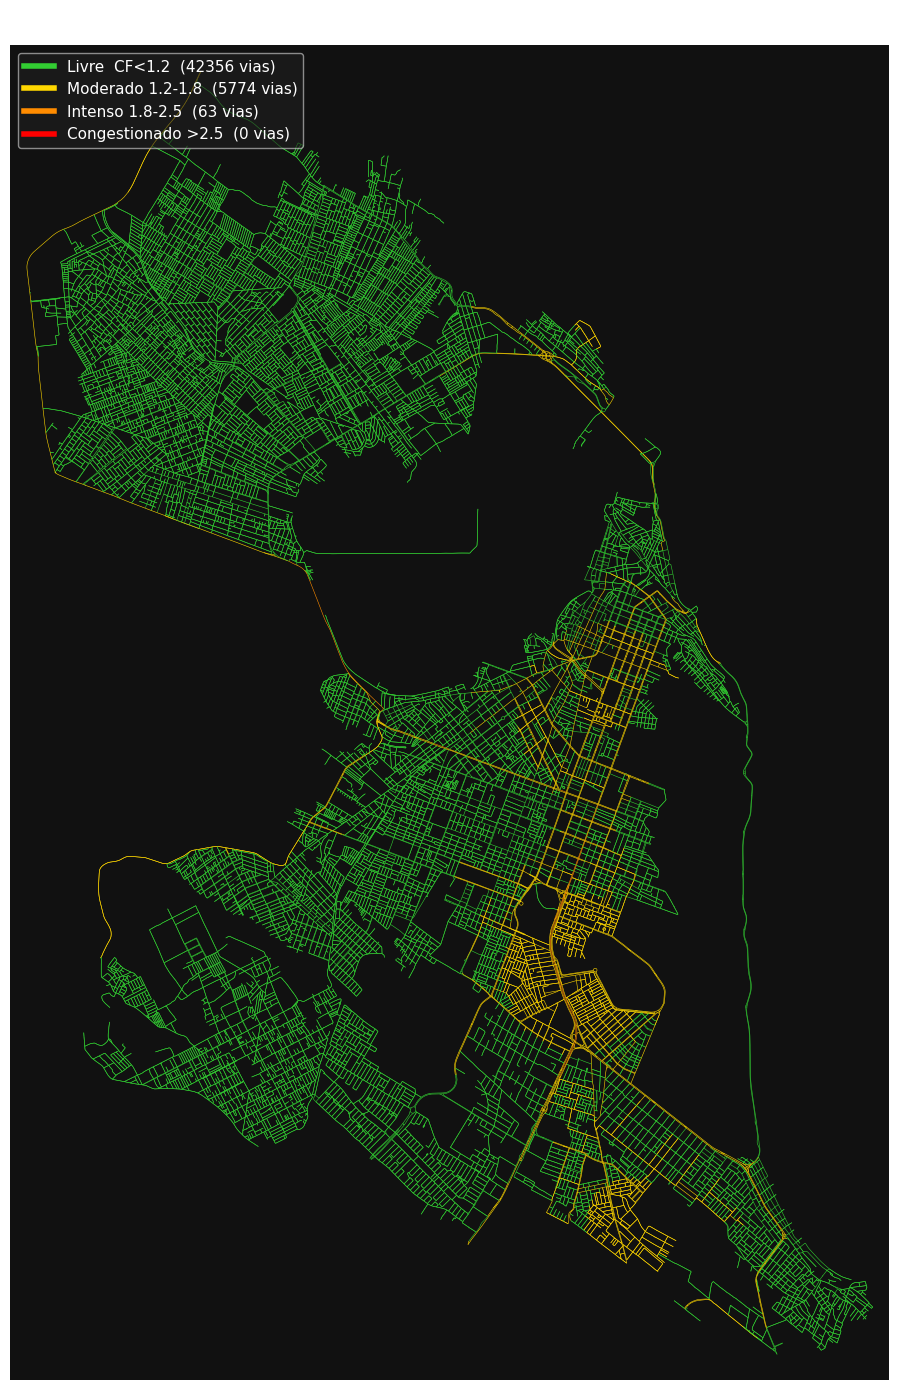

 Mapa salvo com nome: mapa_transito_sintetico.png


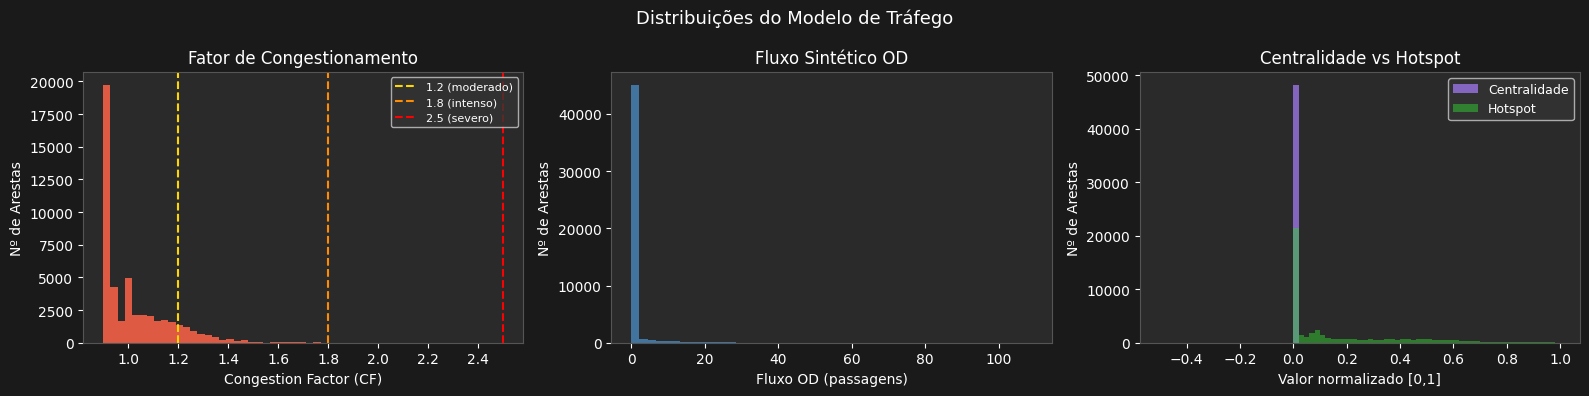

Histogramas salvos: distribuicoes_trafego.png


In [6]:
import matplotlib.lines as mlines
import matplotlib.colors as mcolors

#  Cores por nível de congestionamento


def cor_congestionamento(cf):
    if cf < 1.2:  return 'limegreen'   # livre
    if cf < 1.8:  return 'gold'        # moderado
    if cf < 2.5:  return 'darkorange'  # intenso
    return 'red'                        # severo

edge_colors = [cor_congestionamento(data.get('congestion_factor', 1.0))
    for u, v, k, data in G.edges(keys=True, data=True)
]

# Contagem por nível
n_livre   = edge_colors.count('limegreen')
n_mod     = edge_colors.count('gold')
n_int     = edge_colors.count('darkorange')
n_sev     = edge_colors.count('red')
n_total   = len(edge_colors)

print(f"Total de arestas: {n_total}")
print(f"  Livre       (CF < 1.2):  {n_livre:5d} ({100*n_livre/n_total:.1f}%)")
print(f"  Moderado    (CF 1.2 - 1.8):{n_mod:5d} ({100*n_mod/n_total:.1f}%)")
print(f"  Intenso     (CF 1.8 - 2.5):{n_int:5d} ({100*n_int/n_total:.1f}%)")
print(f"  Congestionado (CF > 2.5):{n_sev:5d} ({100*n_sev/n_total:.1f}%)")

# Mapa da cidade por congestionamento
print("\n Gerando mapa de Natal/RN ")
print("\n Carregando... ")

fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_color=edge_colors,
    edge_linewidth=0.4,
    bgcolor='#111111',
    show=False,
    close=False,
    figsize=(14, 14),
)

ax.set_title(f" Trânsito Sintético — Natal/RN  |  Período: {PERIODO_TRAFEGO.replace('_',' ').title()}",
    fontsize=14, color='white', pad=14
)

legend_els = [
    mlines.Line2D([0],[0], color='limegreen',  lw=4, label=f'Livre  CF<1.2  ({n_livre} vias)'),
    mlines.Line2D([0],[0], color='gold',        lw=4, label=f'Moderado 1.2-1.8  ({n_mod} vias)'),
    mlines.Line2D([0],[0], color='darkorange',  lw=4, label=f'Intenso 1.8-2.5  ({n_int} vias)'),
    mlines.Line2D([0],[0], color='red',         lw=4, label=f'Congestionado >2.5  ({n_sev} vias)'),
]

ax.legend(handles=legend_els, loc='upper left', fontsize=11, facecolor='#1e1e1e', labelcolor='white', framealpha=0.65)
plt.tight_layout()
plt.savefig('mapa_transito_sintetico.png', dpi=150, facecolor='#111111', bbox_inches='tight')
plt.show()
print(" Mapa salvo com nome: mapa_transito_sintetico.png")

#  Histogramas de CF e Fluxo
cfs   = [d.get('congestion_factor', 1.0) for _, _, d in G.edges(data=True)]
flows = [d.get('synthetic_flow',    0.0) for _, _, d in G.edges(data=True)]
bets  = [d.get('betweenness',       0.0) for _, _, d in G.edges(data=True)]
hots  = [d.get('hotspot_factor',    0.0) for _, _, d in G.edges(data=True)]

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4), facecolor='#1a1a1a')
fig2.suptitle('Distribuições do Modelo de Tráfego', color='white', fontsize=13)

for ax2 in axes2:
    ax2.set_facecolor('#2a2a2a')
    ax2.tick_params(colors='white')
    for spine in ax2.spines.values():
        spine.set_edgecolor('#555')

axes2[0].hist(cfs, bins=50, color='tomato', edgecolor='none', alpha=0.85)
axes2[0].axvline(1.2, color='gold',       linestyle='--', lw=1.5, label='1.2 (moderado)')
axes2[0].axvline(1.8, color='darkorange', linestyle='--', lw=1.5, label='1.8 (intenso)')
axes2[0].axvline(2.5, color='red',        linestyle='--', lw=1.5, label='2.5 (severo)')
axes2[0].set_xlabel('Congestion Factor (CF)', color='white')
axes2[0].set_ylabel('Nº de Arestas',          color='white')
axes2[0].set_title('Fator de Congestionamento', color='white')
axes2[0].legend(fontsize=8, labelcolor='white', facecolor='#333')

axes2[1].hist(flows, bins=50, color='steelblue', edgecolor='none', alpha=0.85)
axes2[1].set_xlabel('Fluxo OD (passagens)',  color='white')
axes2[1].set_ylabel('Nº de Arestas',          color='white')
axes2[1].set_title('Fluxo Sintético OD',       color='white')

axes2[2].hist(bets, bins=50, color='mediumpurple', edgecolor='none', alpha=0.85, label='Centralidade')
axes2[2].hist(hots, bins=50, color='limegreen',    edgecolor='none', alpha=0.5,  label='Hotspot')
axes2[2].set_xlabel('Valor normalizado [0,1]', color='white')
axes2[2].set_ylabel('Nº de Arestas',            color='white')
axes2[2].set_title('Centralidade vs Hotspot',    color='white')
axes2[2].legend(fontsize=9, labelcolor='white', facecolor='#333')

plt.tight_layout()
plt.savefig('distribuicoes_trafego.png', dpi=130, facecolor='#1a1a1a', bbox_inches='tight')
plt.show()
print("Histogramas salvos: distribuicoes_trafego.png")


## 5. Definição de Origem (A) e Destino (B)

Digite abaixo o **endereço ou nome do local** de origem e destino.
O geocodificador do OSMnx converte o texto em coordenadas e localiza
o nó mais próximo no grafo de Natal.

**Exemplos válidos:**
- `"Universidade Federal do Rio Grande do Norte, Natal"`
- `"Shopping Midway Mall, Natal, RN"`
- `"Praia de Ponta Negra, Natal"`
- `"Rua Mossoró, 100, Tirol, Natal"`


Geocodificando origem:  'Praia shopping, Natal, RN, Brazil'...
Geocodificando destino: 'CMEI Professora Francisca Célia Martins de Souza, Natal, RN, Brazil'...

 Origem  (A): nó 503307654  — lat= -5.866403, lon= -35.185565

 Destino (B): nó 3800981738 — lat= -5.754336, lon= -35.280559


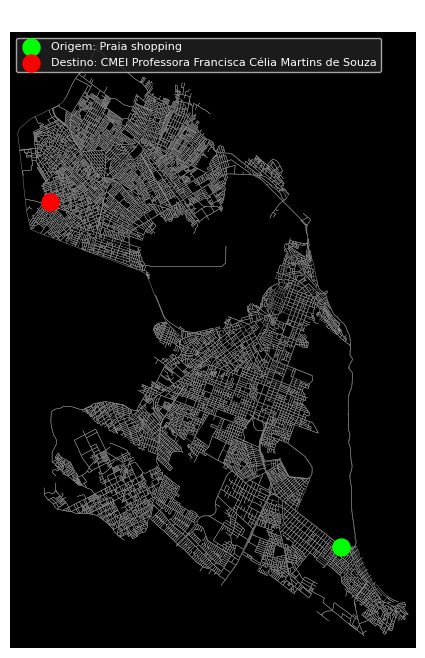

In [7]:
# ── Defina aqui os endereços ─────────────────────────────────────────
# O endereço de destino é um lugar na zona norte da Cidade Escolhido justamente por esta em um ponto muito distante da origem
#ENDERECO_ORIGEM  = "Universidade Federal do Rio Grande do Norte, Natal, RN, Brazil"
ENDERECO_ORIGEM  = "Praia shopping, Natal, RN, Brazil"
ENDERECO_DESTINO = "CMEI Professora Francisca Célia Martins de Souza, Natal, RN, Brazil"


def geocodificar(endereco):
    """
    Converte um endereço em texto para (latitude, longitude)
    usando o Nominatim via OSMnx.
    Lança ValueError se o endereço não for encontrado.
    """

    ponto = ox.geocode(endereco)

    if ponto is None:
        raise ValueError(f"Endereço não encontrado: '{endereco}'")
    return ponto  # (lat, lon)


def endereco_para_no(G, endereco):
    """
    Geocodifica o endereço e retorna o nó do grafo G mais próximo.
    """

    lat, lon = geocodificar(endereco)
    no = ox.distance.nearest_nodes(G, X=lon, Y=lat)

    return no, lat, lon


# Geocodificar origem e destino
print(f"Geocodificando origem:  '{ENDERECO_ORIGEM}'...")
origem,  lat_orig,  lon_orig  = endereco_para_no(G, ENDERECO_ORIGEM)

print(f"Geocodificando destino: '{ENDERECO_DESTINO}'...")
destino, lat_dest,  lon_dest  = endereco_para_no(G, ENDERECO_DESTINO)

print(f"\n Origem  (A): nó {origem}  — lat= {lat_orig:.6f}, lon= {lon_orig:.6f}")
print(f"\n Destino (B): nó {destino} — lat= {lat_dest:.6f}, lon= {lon_dest:.6f}")

if origem == destino:
    raise ValueError("Origem e destino resultaram no mesmo nó. Use endereços mais distantes.")

# Visualização
ox_fig, ox_ax = ox.plot_graph(
    G, node_size=0, edge_linewidth=0.3,
    show=False, close=False, bgcolor='k'
)

ox_ax.scatter(lon_orig,  lat_orig,  c='lime', s=150, zorder=5, label=f'Origem: {ENDERECO_ORIGEM.split(",")[0]}')
ox_ax.scatter(lon_dest,  lat_dest,  c='red',  s=150, zorder=5, label=f'Destino: {ENDERECO_DESTINO.split(",")[0]}')
ox_ax.legend(loc='upper left', fontsize=8, facecolor='#222', labelcolor='white')
plt.title("Grafo de Natal — Origem e Destino", color='white')
plt.show()


## 6. Implementação dos Algoritmos de Caminho Mínimo

Os quatro algoritmos exigidos são implementados sobre o grafo NetworkX
usando o atributo `weight` como parâmetro, o que permite reutilizá-los
com qualquer função de custo (`length`, `travel_time`, `traffic_time`).

### 6.1 Dijkstra Simples (sem heap — O(V²))


In [8]:
def dijkstra_simples(G, source, weight="length"):
    """
    Dijkstra sem fila de prioridade (O(V²)).
    Retorna (dist, prev) onde:
      dist[v] = menor custo de source até v
      prev[v] = nó anterior no caminho mínimo
    """

    dist = {n: float("inf") for n in G.nodes}
    prev = {n: None for n in G.nodes}
    dist[source] = 0.0
    unvisited = set(G.nodes)

    while unvisited:
        # Seleciona o nó não visitado com menor distância (O(V))
        u = min(unvisited, key=lambda n: dist[n])
        if dist[u] == float("inf"):
            break
        unvisited.remove(u)

        for v, edge_data in G[u].items():
            # Pega o menor peso entre as arestas paralelas (MultiDiGraph)
            w = min(d.get(weight, float("inf")) for d in edge_data.values())
            alt = dist[u] + w
            if alt < dist[v]:
                dist[v] = alt
                prev[v] = u

    return dist, prev


def reconstruir_caminho(prev, source, target):
    """Reconstrói o caminho de source até target a partir do dicionário prev."""

    caminho = []
    no = target

    while no is not None:
        caminho.append(no)
        no = prev[no]
        if caminho and caminho[-1] == source:
            break
    caminho.reverse()
    if not caminho or caminho[0] != source:
        return []
    return caminho


print("Dijkstra simples definido.")


Dijkstra simples definido.


### 6.2 Dijkstra com Heap (O((V + E) log V))

In [9]:
def dijkstra_heap(G, source, weight="length"):
    """
    Dijkstra com fila de prioridade (min-heap) — O((V+E) log V).
    """
    dist = {n: float("inf") for n in G.nodes}
    prev = {n: None for n in G.nodes}
    dist[source] = 0.0
    heap = [(0.0, source)]  # (custo, nó)

    while heap:
        custo_u, u = heapq.heappop(heap)
        if custo_u > dist[u]:
            continue  # entrada desatualizada

        for v, edge_data in G[u].items():
            w = min(d.get(weight, float("inf")) for d in edge_data.values())
            alt = dist[u] + w
            if alt < dist[v]:
                dist[v] = alt
                prev[v] = u
                heapq.heappush(heap, (alt, v))

    return dist, prev


print("Dijkstra com Heap definido.")


Dijkstra com Heap definido.


### 6.3 A* com Heurística Geográfica

A heurística é a **distância Haversine** (distância real em linha reta
entre dois pontos geográficos), que é admissível pois nunca superestima
o custo real (`length` em metros).


In [10]:
def haversine(lat1, lon1, lat2, lon2):
    """Distância em metros entre dois pontos geográficos (heurística admissível)."""

    R = 6_371_000  # raio da Terra em metros
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlam / 2) ** 2

    return 2 * R * math.asin(math.sqrt(a))


def a_star(G, source, target, weight="length"):
    """
    A* com heurística geográfica (Haversine).
    Retorna (dist, prev, nos_expandidos).
    """
    t_lat = G.nodes[target]["y"]
    t_lon = G.nodes[target]["x"]

    dist = {n: float("inf") for n in G.nodes}
    prev = {n: None for n in G.nodes}
    dist[source] = 0.0
    nos_expandidos = 0

    # heap: (f = g + h, g, nó)
    heap = [(haversine(G.nodes[source]["y"], G.nodes[source]["x"], t_lat, t_lon), 0.0, source)]

    while heap:
        f, g, u = heapq.heappop(heap)
        if g > dist[u]:
            continue
        nos_expandidos += 1
        if u == target:
            break

        for v, edge_data in G[u].items():
            w = min(d.get(weight, float("inf")) for d in edge_data.values())
            g_new = dist[u] + w
            if g_new < dist[v]:
                dist[v] = g_new
                prev[v] = u
                h = haversine(G.nodes[v]["y"], G.nodes[v]["x"], t_lat, t_lon)
                heapq.heappush(heap, (g_new + h, g_new, v))

    return dist, prev, nos_expandidos


print("A* definido.")


A* definido.


### 6.4 Algoritmo Adicional: Bellman-Ford

O **Bellman-Ford** resolve o problema de caminho mínimo com complexidade
O(V × E). Diferente do Dijkstra, suporta pesos negativos, embora aqui
os pesos sejam sempre positivos. É útil como referência de corretude e
para grafos com características adversas. Relaxa todas as arestas V−1
vezes, garantindo a convergência ao caminho ótimo.


In [11]:
def bellman_ford(G, source, weight="length"):
    dist = {n: float("inf") for n in G.nodes}
    prev = {n: None for n in G.nodes}

    dist[source] = 0.0

    V = len(G.nodes)

    for _ in range(V - 1):
        atualizado = False

        for u, v, k, data in G.edges(keys=True, data=True):

            w = data.get(weight, float("inf"))

            if (
                dist[u] != float("inf")
                and dist[u] + w < dist[v]
            ):
                dist[v] = dist[u] + w
                prev[v] = u
                atualizado = True

        if not atualizado:
            break

    # Detecção de ciclo negativo
    for u, v, k, data in G.edges(keys=True, data=True):

        w = data.get(weight, float("inf"))

        if (
            dist[u] != float("inf")
            and dist[u] + w < dist[v]
        ):
            raise ValueError(
                "Ciclo negativo detectado."
            )

    return dist, prev

print("Bellman-Ford definido.")

Bellman-Ford definido.


## 7. Lógica Central: Seleção do Ponto de Embarque

O usuário informa a distância máxima de caminhada `X` (em metros).
O algoritmo:
1. Filtra todos os pontos de embarque de carro (`pickup_nodes`) a ≤ X metros a pé da origem.
2. Para cada candidato `P`, calcula o custo total `A→P (a pé) + P→B (carro)`.
3. Escolhe o `P` com menor custo total.

O ponto `P` representa onde o usuário embarca em um táxi ou veículo
de ride-sharing para completar o trajeto até o destino `B`.


In [22]:
# Grafo pedestre (para calcular caminhada A→P)
G_walk = ox.graph_from_place(place, network_type="walk")

WALK_SPEED_KPH = 5.0  # velocidade média de caminhada

# Define a velocidade para todas as arestas
for _, _, _, data in G_walk.edges(keys=True, data=True):
    data["speed_kph"] = WALK_SPEED_KPH

# Calcula o tempo de viagem em cada aresta
G_walk = ox.add_edge_travel_times(G_walk)

print("Grafo pedestre carregado.")

Grafo pedestre carregado.


In [23]:
def encontrar_melhor_embarque(origem, destino, pickup_nodes, max_walk_m,
                               weight_walk="length", weight_drive="length",
                               G_drive=G, G_ped=G_walk):
    """
    Retorna dict com o melhor ponto P e os dados da rota completa.
    pickup_nodes: lista de nós candidatos a ponto de embarque de carro.
    """
    # físico de caminhada (max_walk_m sempre significa metros).
    dist_walk_metros, _ = dijkstra_heap(G_ped, origem, weight="length")

    # Custo de caminhada no peso efetivamente pedido pelo cenário
    # (pode ser tempo, se for isso que está sendo otimizado)
    if weight_walk == "length":
        dist_walk, prev_walk = dist_walk_metros, _
    else:
        dist_walk, prev_walk = dijkstra_heap(G_ped, origem, weight=weight_walk)

    candidatos = [p for p in pickup_nodes
                  if dist_walk_metros.get(p, float("inf")) <= max_walk_m]

    if not candidatos:
        return None

    melhor = None
    melhor_custo = float("inf")

    for P in candidatos:
        custo_caminhada = dist_walk[P]
        dist_drive, _ = dijkstra_heap(G_drive, P, weight=weight_drive)
        custo_carro = dist_drive.get(destino, float("inf"))
        custo_total = custo_caminhada + custo_carro

        if custo_total < melhor_custo:
            melhor_custo = custo_total
            melhor = {
                "P": P,
                "custo_caminhada": custo_caminhada,
                "custo_carro": custo_carro,
                "custo_total": custo_total,
                "prev_walk": prev_walk,
            }

    return melhor

# ajustado para uma caminhada proxima
MAX_WALK_METROS = 500

resultado = encontrar_melhor_embarque(origem, destino, pickup_nodes, MAX_WALK_METROS)

if resultado:
    print(f"  Melhor ponto de embarque P: {resultado['P']}")
    print(f"  Caminhada A → P: {resultado['custo_caminhada']:.1f} m")
    print(f"  Carro     P → B: {resultado['custo_carro']:.1f} m")
    print(f"  Total:  {resultado['custo_caminhada']:.1f}m + {resultado['custo_carro']:.1f}m  = {resultado['custo_total']:.1f} m")
else:
    print(f"Nenhum ponto de embarque a menos de {MAX_WALK_METROS} m da origem.")


  Melhor ponto de embarque P: 503307536
  Caminhada A → P: 219.0 m
  Carro     P → B: 18825.5 m
  Total:  219.0m + 18825.5m  = 19044.4 m


## 8. Comparação dos 5 Cenários Exigidos

| # | Cenário | Peso usado |
|---|---------|-----------|
| 1 | Menor distância total | `length` |
| 2 | Mais rápido sem trânsito | `travel_time` |
| 3 | Mais rápido com trânsito sintético | `traffic_time` |
| 4 | Sem caminhada (carro direto A→B) | `length` / `travel_time` |
| 5 | Ganho ao caminhar até outro ponto | comparação entre P ótimo e P=origem |


In [24]:
def cenario(label, weight_walk, weight_drive, G_drive=G, G_ped=G_walk, max_walk=MAX_WALK_METROS):

    t0 = time.perf_counter()

    res = encontrar_melhor_embarque(origem, destino, pickup_nodes, max_walk,
                                    weight_walk=weight_walk,
                                    weight_drive=weight_drive,
                                    G_drive=G_drive, G_ped=G_ped)

    elapsed = time.perf_counter() - t0

    if res:
        print(f"\n{'─'*55}")
        print(f"Cenário: {label}")
        print(f"  P = {res['P']}")
        print(f"  Caminhada ({weight_walk}): {res['custo_caminhada']:.2f}")
        print(f"  Carro     ({weight_drive}): {res['custo_carro']:.2f}")
        print(f"  Total:    {res['custo_total']:.2f}")
        print(f"  Tempo de execução: {elapsed:.3f} s")
    else:
        print(f"\nCenário {label}: sem candidatos a {max_walk} m")
    return res, elapsed

# Cenário 1: menor distância
c1, t1 = cenario("1 — Menor distância (length)", "length", "length")

# Cenário 2: mais rápido sem trânsito
c2, t2 = cenario("2 — Mais rápido sem trânsito (travel_time)", "travel_time", "travel_time")

# Cenário 3: mais rápido com trânsito sintético
c3, t3 = cenario("3 — Mais rápido com trânsito sintético (traffic_time)", "travel_time", "traffic_time")

# Cenário 4: sem caminhada — rota direta A→B de carro
t0 = time.perf_counter()
dist_direto, prev_direto = dijkstra_heap(G, origem, weight="length")
t4 = time.perf_counter() - t0
custo_direto = dist_direto.get(destino, float("inf"))

print(f"\n{'─'*55}")
print(f"Cenário 4 — Sem caminhada (carro direto A→B)")
print(f"  Distância: {custo_direto:.2f} m")
print(f"  Tempo de execução: {t4:.3f} s")

# Cenário 5: ganho ao caminhar
if c1 and custo_direto != float("inf"):
    ganho = custo_direto - c1["custo_total"]
    print(f"\n{'─'*55}")
    print(f"Cenário 5 — Ganho ao caminhar até P ótimo")
    print(f"  Rota direta:     {custo_direto:.2f} m")
    print(f"  Com caminhada:   {c1['custo_total']:.2f} m")
    print(f"  Ganho:           {ganho:.2f} m ({'positivo ✓' if ganho > 0 else 'negativo — caminhar não compensa'})")



───────────────────────────────────────────────────────
Cenário: 1 — Menor distância (length)
  P = 503307536
  Caminhada (length): 218.96
  Carro     (length): 18825.46
  Total:    19044.42
  Tempo de execução: 1.537 s

───────────────────────────────────────────────────────
Cenário: 2 — Mais rápido sem trânsito (travel_time)
  P = 2625555967
  Caminhada (travel_time): 22.47
  Carro     (travel_time): 1263.26
  Total:    1285.73
  Tempo de execução: 1.762 s

───────────────────────────────────────────────────────
Cenário: 3 — Mais rápido com trânsito sintético (traffic_time)
  P = 2625555967
  Caminhada (travel_time): 22.47
  Carro     (traffic_time): 1727.10
  Total:    1749.57
  Tempo de execução: 2.099 s

───────────────────────────────────────────────────────
Cenário 4 — Sem caminhada (carro direto A→B)
  Distância: 19155.77 m
  Tempo de execução: 0.477 s

───────────────────────────────────────────────────────
Cenário 5 — Ganho ao caminhar até P ótimo
  Rota direta:     19155.77

## 9. Comparação de Algoritmos

Executamos os 4 algoritmos na mesma rota `origem → destino` com peso
`length` e medimos:
- distância encontrada (devem ser iguais — validação de corretude);
- nós expandidos (quando disponível);
- tempo de execução.


In [25]:
resultados = {}

# ─ Dijkstra Simples ─

print("Rodando Dijkstra Simples...")

t0 = time.perf_counter()
dist_s, prev_s = dijkstra_simples(G, origem, weight="length")

resultados["Dijkstra Simples"] = {
    "dist": dist_s.get(destino, float("inf")),
    "tempo": time.perf_counter() - t0,
    "nos_expandidos": "N/A"
}

print(f" {resultados['Dijkstra Simples']['dist']:.1f} m em {resultados['Dijkstra Simples']['tempo']:.3f} s")

# ─ Dijkstra com Heap ─
t0 = time.perf_counter()
dist_h, prev_h = dijkstra_heap(G, origem, weight="length")

resultados["Dijkstra Heap"] = {
    "dist": dist_h.get(destino, float("inf")),
    "tempo": time.perf_counter() - t0,
    "nos_expandidos": "N/A"
}
print(f" {resultados['Dijkstra Heap']['dist']:.1f} m em {resultados['Dijkstra Heap']['tempo']:.3f} s")

# ─ A* ─
t0 = time.perf_counter()
dist_a, prev_a, nos_a = a_star(G, origem, destino, weight="length")

resultados["A*"] = {
    "dist": dist_a.get(destino, float("inf")),
    "tempo": time.perf_counter() - t0,
    "nos_expandidos": nos_a
}
print(f"  {resultados['A*']['dist']:.1f} m em {resultados['A*']['tempo']:.3f} s | nós expandidos: {nos_a}")

print("Rodando Bellman-Ford (subgrafo próximo à origem)...")

# Garante que o raio do subgrafo seja sempre maior que a distância real
# já conhecida (Dijkstra Heap), evitando que o destino fique de fora do ego_graph
margem = 1.2  # 20% de margem de segurança
raio_bf = dist_h.get(destino, float("inf")) * margem
ego = nx.ego_graph(G, origem, radius=raio_bf, distance="length")
t0 = time.perf_counter()

if destino in ego.nodes:
    dist_bf, prev_bf = bellman_ford(ego, origem, weight="length")
    dist_bf_val = dist_bf.get(destino, float("inf"))
else:
    dist_bf_val = float("inf")
    prev_bf = {}

resultados["Bellman-Ford*"] = {
    "dist": dist_bf_val,
    "tempo": time.perf_counter() - t0,
    "nos_expandidos": "N/A"
}
print(f"  {dist_bf_val:.1f} m em {resultados['Bellman-Ford*']['tempo']:.3f} s")
print(f"  * Bellman-Ford executado em subgrafo local (raio {raio_bf/1000:.1f} km) por eficiência.")

# ── Tabela comparativa ──
print(f"\n{'Algoritmo':<22} {'Distância (m)':>15} {'Tempo (s)':>12} {'Nós Expandidos':>16}")
print("─" * 68)
for nome, r in resultados.items():
    d = f"{r['dist']:.1f}" if r['dist'] != float("inf") else "∞"
    print(f"{nome:<22} {d:>15} {r['tempo']:>12.4f} {str(r['nos_expandidos']):>16}")


Rodando Dijkstra Simples...
 19155.8 m em 34.011 s
 19155.8 m em 0.305 s
  19155.8 m em 0.190 s | nós expandidos: 7311
Rodando Bellman-Ford (subgrafo próximo à origem)...
  19155.8 m em 9.461 s
  * Bellman-Ford executado em subgrafo local (raio 23.0 km) por eficiência.

Algoritmo                Distância (m)    Tempo (s)   Nós Expandidos
────────────────────────────────────────────────────────────────────
Dijkstra Simples               19155.8      34.0114              N/A
Dijkstra Heap                  19155.8       0.3050              N/A
A*                             19155.8       0.1897             7311
Bellman-Ford*                  19155.8       9.4612              N/A


## 10. Visualização das Rotas

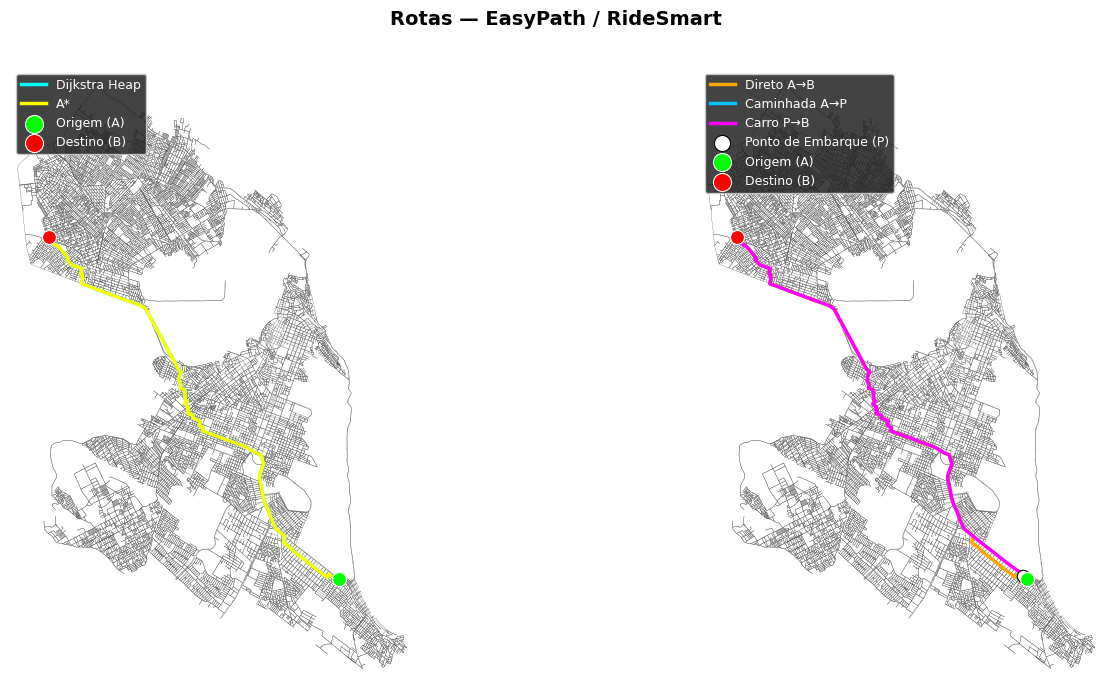

Figura salva como rotas_ridesmart.png


In [29]:
def plotar_rota(G, prev, source, target, ax, color, label, weight="length"):
    """Plota um caminho reconstruído sobre um eixo matplotlib existente."""
    caminho = reconstruir_caminho(prev, source, target)
    if not caminho:
        print(f"Caminho não encontrado para '{label}'")
        return
    xs = [G.nodes[n]["x"] for n in caminho]
    ys = [G.nodes[n]["y"] for n in caminho]
    ax.plot(xs, ys, color=color, linewidth=2.5, label=label, zorder=4)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Rotas — EasyPath / RideSmart", fontsize=14, fontweight="bold")

for ax in axes:
    ox.plot_graph(G, ax=ax, node_size=0, edge_linewidth=0.2,
                  edge_color="#444444", bgcolor="k", show=False, close=False)

# Painel esquerdo: Dijkstra Heap vs A*
ax = axes[0]
ax.set_title("Dijkstra Heap vs A*", color="white")
plotar_rota(G, prev_h, origem, destino, ax, "cyan",  "Dijkstra Heap")
plotar_rota(G, prev_a, origem, destino, ax, "yellow", "A*")
# FIX: label= adicionado para os pontos aparecerem na legenda
ax.scatter(G.nodes[origem]["x"],  G.nodes[origem]["y"],  c="lime", s=100, zorder=6,
           edgecolors="white", linewidths=0.8, label="Origem (A)")
ax.scatter(G.nodes[destino]["x"], G.nodes[destino]["y"], c="red",  s=100, zorder=6,
           edgecolors="white", linewidths=0.8, label="Destino (B)")
ax.legend(loc="upper left", fontsize=9, facecolor="#222", labelcolor="white",
          framealpha=0.85, markerscale=1.3)

# Painel direito: Sem caminhada vs Com caminhada (cenário 1)
ax = axes[1]
ax.set_title("Direto (A→B) vs Com Embarque (A→P→B)", color="white")
plotar_rota(G, prev_direto, origem, destino, ax, "orange", "Direto A→B")
if c1:
    P = c1["P"]
    plotar_rota(G_walk, c1["prev_walk"], origem, P, ax, "deepskyblue", "Caminhada A→P")
    dist_p, prev_p = dijkstra_heap(G, P, weight="length")
    plotar_rota(G, prev_p, P, destino, ax, "magenta", "Carro P→B")
    # FIX: label= adicionado para o ponto de embarque aparecer na legenda
    ax.scatter(G.nodes[P]["x"], G.nodes[P]["y"], c="white", s=80, zorder=6,
               edgecolors="black", linewidths=0.8, label="Ponto de Embarque (P)")
ax.scatter(G.nodes[origem]["x"],  G.nodes[origem]["y"],  c="lime", s=100, zorder=6,
           edgecolors="white", linewidths=0.8, label="Origem (A)")
ax.scatter(G.nodes[destino]["x"], G.nodes[destino]["y"], c="red",  s=100, zorder=6,
           edgecolors="white", linewidths=0.8, label="Destino (B)")
ax.legend(loc="upper left", fontsize=9, facecolor="#222", labelcolor="white",
          framealpha=0.85, markerscale=1.3)

plt.tight_layout()
plt.savefig("rotas_ridesmart.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figura salva como rotas_ridesmart.png")

## 10.1 Caminho Direto A → B (carro, sem caminhada)

Plot dedicado mostrando **apenas** a rota direta de carro entre a origem `A`
e o destino `B`, sem passar por nenhum ponto de embarque intermediário.
Serve como referência de base (*baseline*) para comparar com as rotas
que incluem o trecho de caminhada (Seção 7 e 8).


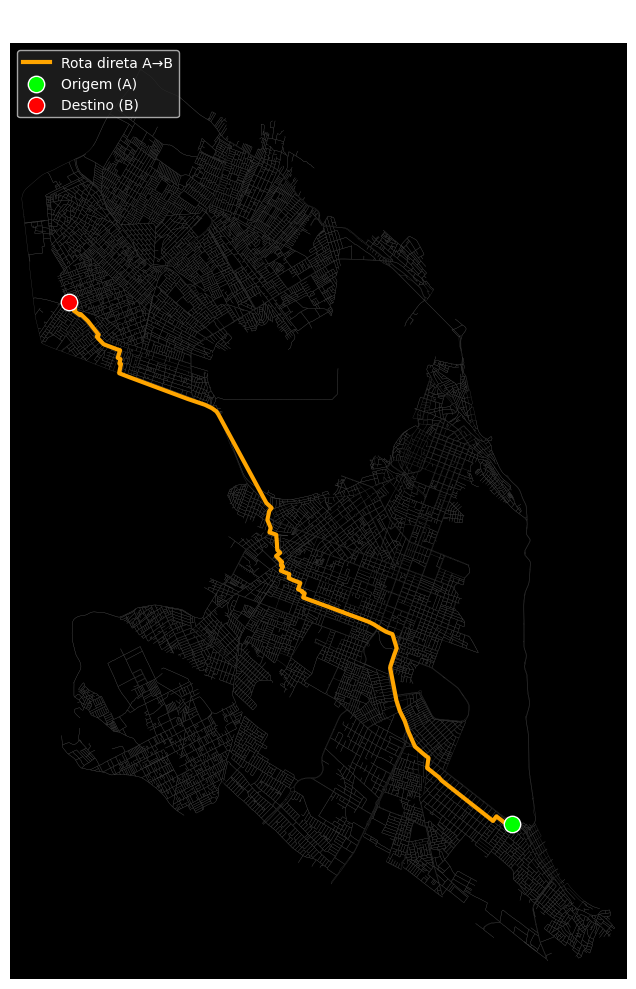

Distância da rota direta A→B: 19155.8 m
Nós no caminho: 187
Figura salva como caminho_direto_AB.png


In [28]:
# Calcula a rota direta A→B de carro (peso: distância)
dist_direto_ab, prev_direto_ab = dijkstra_heap(G, origem, weight="length")
caminho_direto_ab = reconstruir_caminho(prev_direto_ab, origem, destino)

if not caminho_direto_ab:
    print("Não foi encontrada rota direta entre A e B.")
else:
    custo_direto_ab = dist_direto_ab[destino]

    fig, ax = ox.plot_graph(
        G, node_size=0, edge_linewidth=0.2, edge_color="#444444",
        bgcolor="k", show=False, close=False, figsize=(10, 10)
    )

    xs = [G.nodes[n]["x"] for n in caminho_direto_ab]
    ys = [G.nodes[n]["y"] for n in caminho_direto_ab]
    ax.plot(xs, ys, color="orange", linewidth=3, label="Rota direta A→B", zorder=4)

    ax.scatter(G.nodes[origem]["x"],  G.nodes[origem]["y"],  c="lime", s=140,
               zorder=6, label="Origem (A)", edgecolors="white")
    ax.scatter(G.nodes[destino]["x"], G.nodes[destino]["y"], c="red",  s=140,
               zorder=6, label="Destino (B)", edgecolors="white")

    ax.set_title(f"Caminho Direto A→B  —  {custo_direto_ab:.0f} m",
                 fontsize=14, color="white", pad=14)
    ax.legend(loc="upper left", fontsize=10, facecolor="#222", labelcolor="white")

    plt.tight_layout()
    plt.savefig("caminho_direto_AB.png", dpi=130, bbox_inches="tight")
    plt.show()

    print(f"Distância da rota direta A→B: {custo_direto_ab:.1f} m")
    print(f"Nós no caminho: {len(caminho_direto_ab)}")
    print("Figura salva como caminho_direto_AB.png")

## 13. Comparação Visual com Zoom: A→P (caminhada) + P→B (carro) por Algoritmo

Para visualizar com clareza o trajeto completo (caminhada até o ponto de
embarque + trecho de carro), recortamos um subgrafo local em torno de P
(grande o suficiente para conter B) e rodamos os 4 algoritmos a partir
desse ponto. Isso torna viável rodar Dijkstra Simples e Bellman-Ford
em tempo hábil, já que a comparação de eficiência em escala já foi feita
na Seção 9.

Subgrafo local: 18564 nós (grafo completo tinha 18581)
Raio usado: 24473 m

Rodando os 4 algoritmos no subgrafo local...
  Dijkstra Simples: 18825.5 m (34.276s)
  Dijkstra Heap:    18825.5 m (0.210s)
  A*:               18825.5 m (0.110s | nós expandidos: 7241)
  Bellman-Ford:     18825.5 m (8.459s)

Todos os algoritmos concordam? True


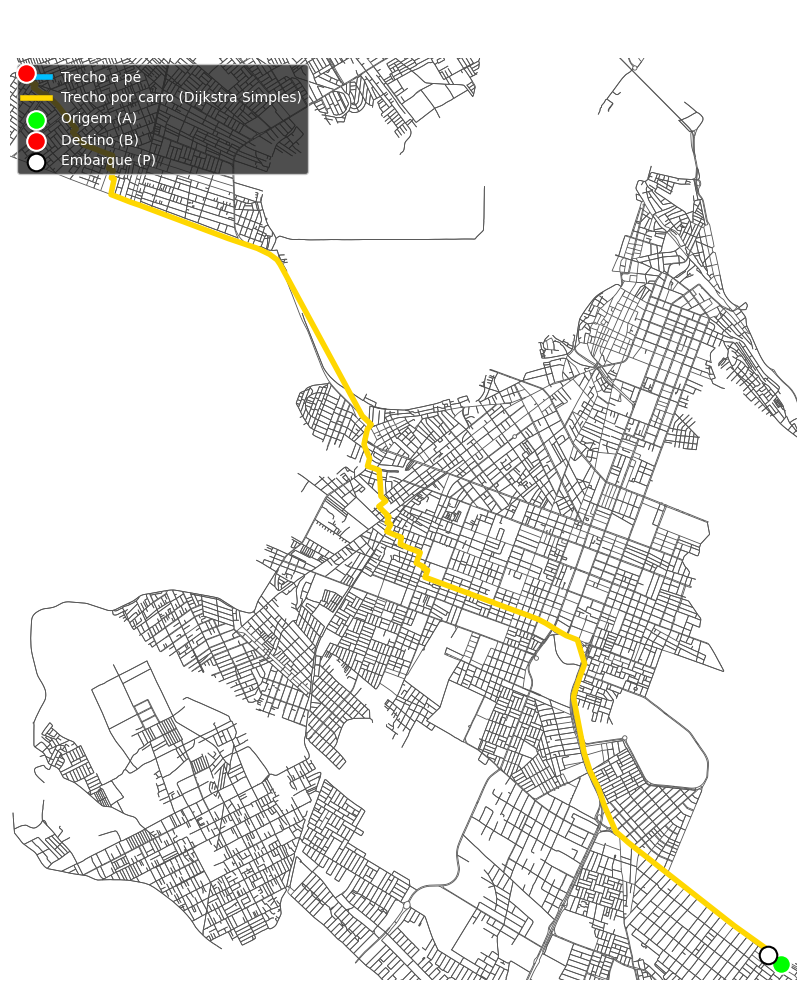

Imagem salva: rota_dijkstra_simples.png


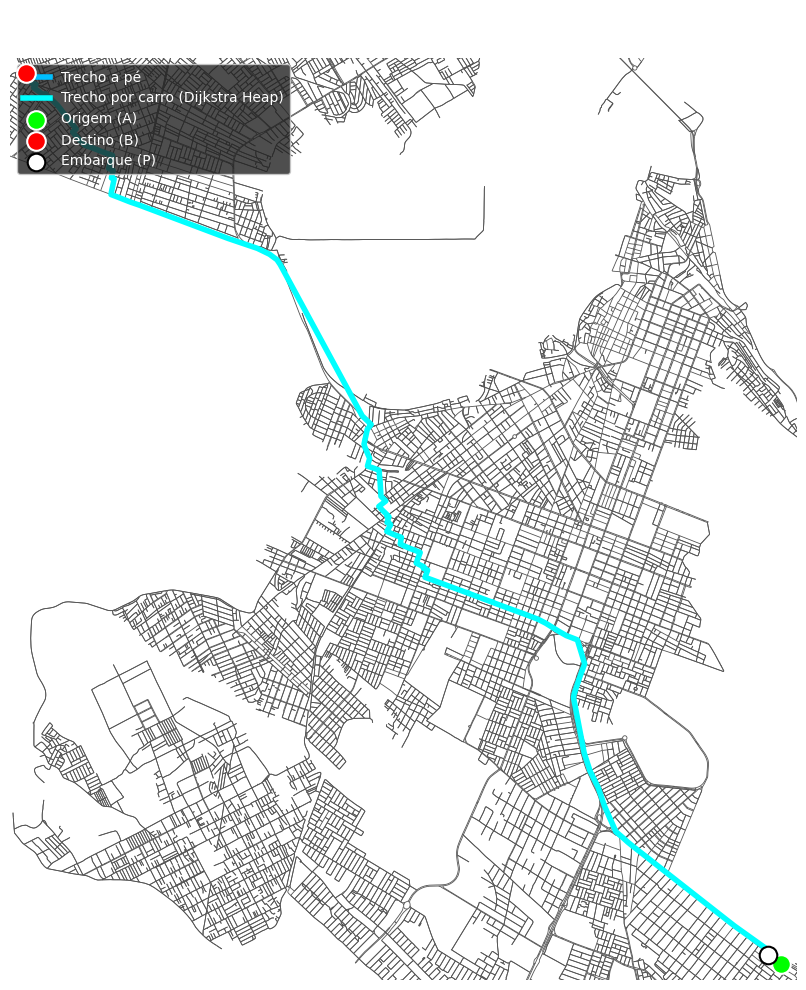

Imagem salva: rota_dijkstra_heap.png


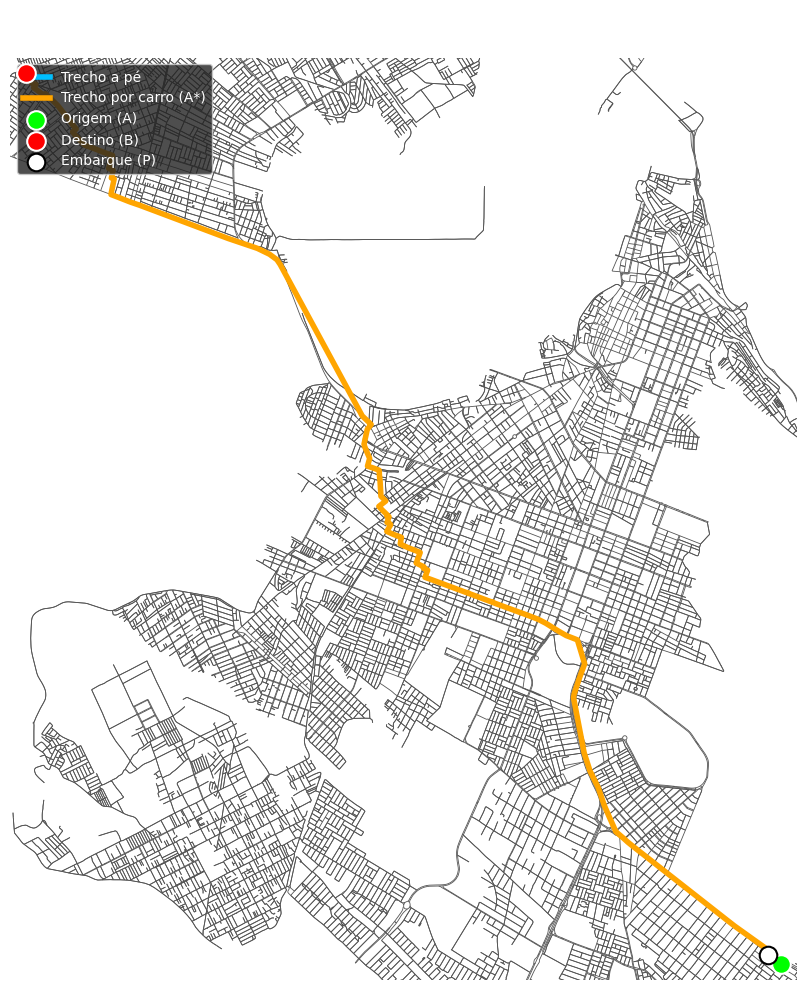

Imagem salva: rota_aastar.png


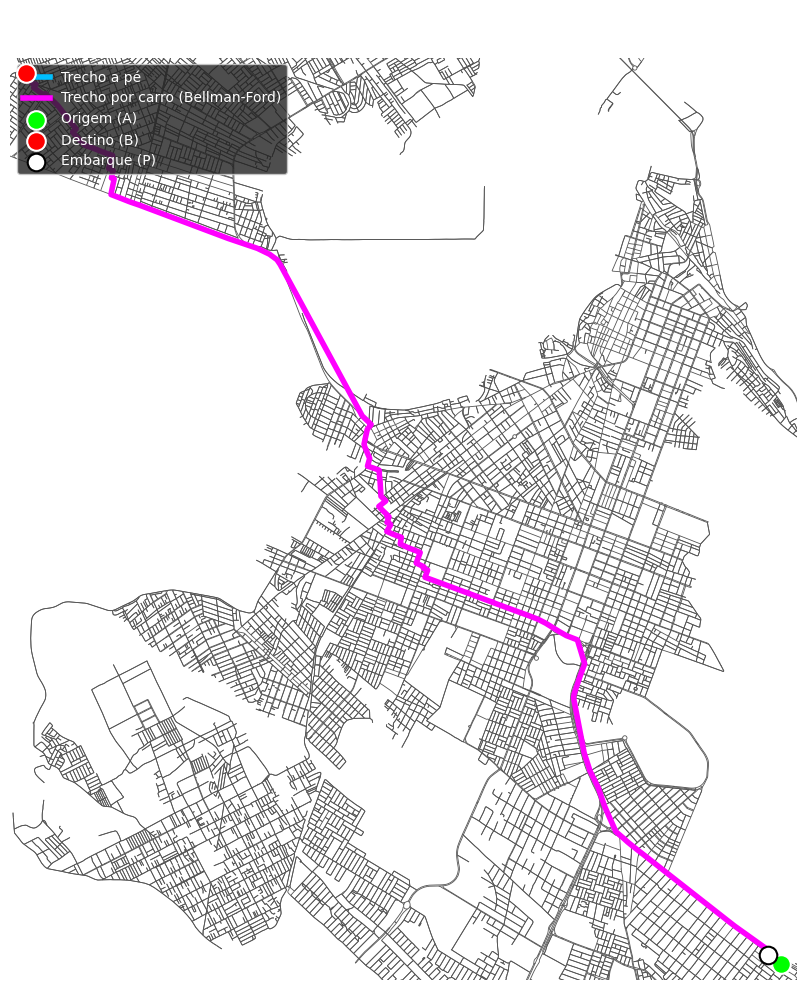

Imagem salva: rota_bellman-ford.png


In [27]:
# ============================================================
# 13. Comparação Visual com Zoom: A→P (caminhada) + P→B (carro) por Algoritmo
# ============================================================

# ── 1. Subgrafo local em torno de P, garantindo que B esteja dentro ──
P = c1["P"]
raio_sub = c1["custo_carro"] * 1.3  # folga de 30% sobre a distância P→B
G_sub = nx.ego_graph(G, P, radius=raio_sub, distance="length")

while destino not in G_sub.nodes:
    raio_sub *= 1.5
    G_sub = nx.ego_graph(G, P, radius=raio_sub, distance="length")

print(f"Subgrafo local: {G_sub.number_of_nodes()} nós "
      f"(grafo completo tinha {G.number_of_nodes()})")
print(f"Raio usado: {raio_sub:.0f} m\n")

# ── 2. Rodar os 4 algoritmos a partir de P, dentro do subgrafo ──
print("Rodando os 4 algoritmos no subgrafo local...")

t0 = time.perf_counter()
dist_s_P, prev_s_P = dijkstra_simples(G_sub, P, weight="length")
print(f"  Dijkstra Simples: {dist_s_P.get(destino, float('inf')):.1f} m "
      f"({time.perf_counter()-t0:.3f}s)")

t0 = time.perf_counter()
dist_h_P, prev_h_P = dijkstra_heap(G_sub, P, weight="length")
print(f"  Dijkstra Heap:    {dist_h_P.get(destino, float('inf')):.1f} m "
      f"({time.perf_counter()-t0:.3f}s)")

t0 = time.perf_counter()
dist_a_P, prev_a_P, nos_a_P = a_star(G_sub, P, destino, weight="length")
print(f"  A*:               {dist_a_P.get(destino, float('inf')):.1f} m "
      f"({time.perf_counter()-t0:.3f}s | nós expandidos: {nos_a_P})")

t0 = time.perf_counter()
dist_bf_P, prev_bf_P = bellman_ford(G_sub, P, weight="length")
print(f"  Bellman-Ford:     {dist_bf_P.get(destino, float('inf')):.1f} m "
      f"({time.perf_counter()-t0:.3f}s)")

custos = [dist_s_P[destino], dist_h_P[destino], dist_a_P[destino], dist_bf_P[destino]]
print(f"\nTodos os algoritmos concordam? "
      f"{all(abs(c - custos[0]) < 1e-6 for c in custos)}")

# ── 3. Um painel individual por algoritmo, com zoom no trajeto ──
algoritmos = [
    ("Dijkstra Simples", prev_s_P,  dist_s_P,  "gold"),
    ("Dijkstra Heap",    prev_h_P,  dist_h_P,  "cyan"),
    ("A*",               prev_a_P,  dist_a_P,  "orange"),
    ("Bellman-Ford",     prev_bf_P, dist_bf_P, "magenta"),
]

for nome_alg, prev_alg, dist_alg, cor in algoritmos:

    fig, ax = plt.subplots(figsize=(12, 10))

    caminho_walk  = reconstruir_caminho(c1["prev_walk"], origem, P)
    caminho_drive = reconstruir_caminho(prev_alg, P, destino)

    # ── Fundo da rede ──
    ox.plot_graph(G_sub, ax=ax,
        node_size=0,
        edge_color="#555555",
        edge_linewidth=0.6,
        bgcolor="black",
        show=False,
        close=False
    )

    # ── Caminhada A → P ──
    xs_w, ys_w = [], []
    if caminho_walk:
        xs_w = [G_walk.nodes[n]["x"] for n in caminho_walk]
        ys_w = [G_walk.nodes[n]["y"] for n in caminho_walk]
        ax.plot(xs_w, ys_w, linewidth=4, color="deepskyblue", label="Trecho a pé")
    else:
        print(f"[{nome_alg}] Caminho a pé (A→P) não encontrado.")

    # ── Carro P → B ──
    xs_d, ys_d = [], []
    if caminho_drive:
        xs_d = [G_sub.nodes[n]["x"] for n in caminho_drive]
        ys_d = [G_sub.nodes[n]["y"] for n in caminho_drive]
        ax.plot(xs_d, ys_d, linewidth=4, color=cor, label=f"Trecho por carro ({nome_alg})")
    else:
        print(f"[{nome_alg}] Caminho de carro (P→B) não encontrado.")

    # ── Marcadores ──
    ax.scatter(G.nodes[origem]["x"], G.nodes[origem]["y"],
        s=180, c="lime", edgecolors="white", linewidths=1.5, zorder=10, label="Origem (A)")
    ax.scatter(G.nodes[destino]["x"], G.nodes[destino]["y"],
        s=180, c="red", edgecolors="white", linewidths=1.5, zorder=10, label="Destino (B)")
    ax.scatter(G.nodes[P]["x"], G.nodes[P]["y"],
        s=160, c="white", edgecolors="black", linewidths=1.5, zorder=10, label="Embarque (P)")

    # ── Zoom automático no trajeto completo ──
    todas_x = xs_w + xs_d
    todas_y = ys_w + ys_d
    margem = 0.002

    if todas_x and todas_y:
        ax.set_xlim(min(todas_x) - margem, max(todas_x) + margem)
        ax.set_ylim(min(todas_y) - margem, max(todas_y) + margem)

    # ── Título com a distância específica deste algoritmo ──
    distancia = dist_alg.get(destino, float("inf"))
    dist_label = f"{distancia:.1f} m" if distancia != float("inf") else "rota não encontrada"

    ax.set_title(f"{nome_alg}\nDistância: {dist_label}",
        fontsize=16, fontweight="bold", color="white")

    ax.legend(loc="upper left", fontsize=10, facecolor="#222222", labelcolor="white")
    ax.grid(alpha=0.2, linestyle="--")

    plt.tight_layout()

    nome_arquivo = f"rota_{nome_alg.lower().replace('*','astar').replace(' ','_')}.png"
    plt.savefig(nome_arquivo, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Imagem salva: {nome_arquivo}")

## 14. Referências

- Boeing, G. (2017). OSMnx: New methods for acquiring, constructing, analyzing, and visualizing complex street networks. *Computers, Environment and Urban Systems*, 65, 126-139.
- Cormen, T. H. et al. (2009). *Introduction to Algorithms* (3rd ed.). MIT Press.
- Hart, P. E., Nilsson, N. J., & Raphael, B. (1968). A formal basis for the heuristic determination of minimum cost paths. *IEEE Transactions on Systems Science and Cybernetics*, 4(2), 100-107.
- Bellman, R. (1958). On a routing problem. *Quarterly of Applied Mathematics*, 16(1), 87-90.
